# Neural Network Inference — TensorFlow vs. NumPy

**Course reference:** Andrew Ng's Machine Learning Specialization — Course 2 (Advanced Learning Algorithms), Week 1

**Goal of this project:** Implement forward propagation (inference) in a small neural network **three different ways** — using TensorFlow, using vectorized NumPy, and using a manual for-loop in NumPy — and verify all three produce identical results.

**Scope note:** Week 1 of Course 2 only covers *inference* (making predictions with a network whose weights are already known). It does **not** cover *training* (learning weights from data via backpropagation) — that's Week 2 material. So in this project, weights and biases are **hand-set by us**, not learned. This keeps the project honestly scoped to what's actually been taught so far.

## Step 0: Setup — Import Libraries

Before anything else, we import the three libraries this project depends on:

- **`numpy`** — for our from-scratch implementations of forward propagation
- **`matplotlib`** — to visualize our synthetic dataset and the resulting decision boundary
- **`tensorflow`** — to build the "reference" version of the network using `Dense` layers, which we'll compare our NumPy versions against

Run the cell below. If everything is installed correctly, you should see version numbers printed with no errors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__)

NumPy version: 2.5.1
TensorFlow version: 2.21.0


## Step 1: Designing the Problem

Before writing code, let's be clear about what we're building and why.

**Why hand-set weights instead of training a model?**
Week 1 of Course 2 (Advanced Learning Algorithms) teaches *forward propagation* — how a network computes a prediction given weights that already exist. It does **not** cover *training* (learning weights from data via gradient descent / backpropagation) — that's Week 2 material. So in this project, we act as if training already happened elsewhere, and our job is only to implement inference correctly. We will hand-set the weights and biases ourselves.

**Why two input features?**
Using exactly 2 features (`x1`, `x2`) means the entire problem can be visualized in a 2D scatter plot, and the final decision boundary our network produces can be drawn directly on top of it — this is what makes the project visual and portfolio-friendly, mirroring the "Coffee Roasting" style labs from the course.

**Why include a hidden layer (not just one output neuron)?**
A single neuron with a sigmoid activation is just logistic regression — that's already the Week 3 portfolio project. Adding one hidden layer with a few neurons is what makes this genuinely a *neural network*, and lets us demonstrate the general (looped, multi-layer) forward propagation pattern taught this week, rather than a single-neuron special case.

**The setup we'll use:**
- 2 input features: `x1`, `x2`
- 1 hidden layer with 3 neurons (sigmoid activation)
- 1 output neuron (sigmoid activation) producing a probability between 0 and 1
- A synthetic dataset of two classes ("positive" and "negative"), generated as two separated clusters of points — no external dataset needed

### Generating the synthetic dataset

We'll create two clusters of 2D points using NumPy's random number generator:
- Class 0 ("negative") centered around one point in feature space
- Class 1 ("positive") centered around a different, separated point

We use a **fixed random seed** (`np.random.seed(...)`) so that the dataset is reproducible — anyone re-running this notebook gets the exact same points, which matters for a portfolio project (results should be repeatable, not different every run).

In [5]:
# Fixed seed for reproducibility
np.random.seed(42)

n_points_per_class = 50

# Class 0: centered around (2, 2)
class_0 = np.random.randn(n_points_per_class, 2) * 0.75 + np.array([2, 2])

# Class 1: centered around (6, 6)
class_1 = np.random.randn(n_points_per_class, 2) * 0.75 + np.array([6, 6])

# Combine into one dataset
X = np.vstack([class_0, class_1])                       # shape: (100, 2)
y = np.hstack([np.zeros(n_points_per_class),
               np.ones(n_points_per_class)])             # shape: (100,)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 2)
y shape: (100,)


### Visualizing the dataset

Let's plot the two classes to confirm they're visually separable — this is a sanity check before we build any network. If the clusters overlap heavily, a simple network won't be able to separate them cleanly; if they're well-separated (as designed), we should see two distinct groups of points.

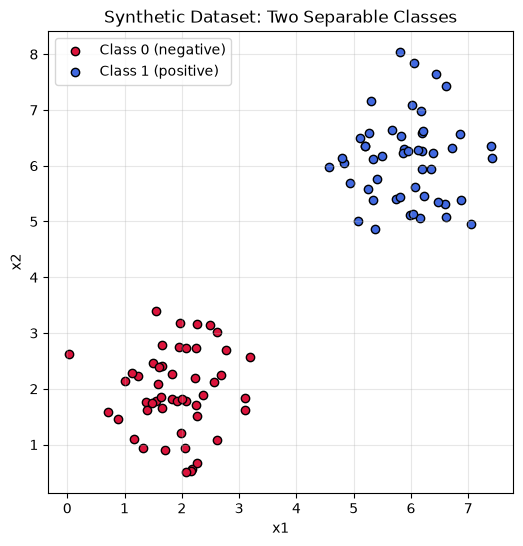

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='crimson', label='Class 0 (negative)', edgecolor='k')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='royalblue', label='Class 1 (positive)', edgecolor='k')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Synthetic Dataset: Two Separable Classes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 2: Building the Network in TensorFlow

We define the network architecture using TensorFlow's `Sequential` API.

**Architecture:**
- Hidden layer: 3 neurons, sigmoid activation, takes in our 2 input features
- Output layer: 1 neuron, sigmoid activation, produces a probability between 0 and 1

In [2]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=3, activation='sigmoid', input_shape=(2,), name='hidden_layer'),
    tf.keras.layers.Dense(units=1, activation='sigmoid', name='output_layer')
])

model.summary()

/Users/bhavyajhalani/ml-portfolio/week4-neural-network-inference/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

### Manually setting the weights

- Hidden layer: `W1` shape `(2, 3)` — 2 inputs → 3 neurons. `b1` shape `(3,)`.
- Output layer: `W2` shape `(3, 1)` — 3 neurons → 1 output. `b2` shape `(1,)`.

Values are hand-picked so the network separates Class 1 (centered near (6,6)) from Class 0 (centered near (2,2)).

In [3]:
W1 = np.array([
    [0.8, 0.5, -0.6],
    [0.8, -0.5, 0.6]
])
b1 = np.array([-4.0, 0.5, 0.5])

W2 = np.array([
    [1.5],
    [1.0],
    [1.0]
])
b2 = np.array([-1.5])

model.get_layer('hidden_layer').set_weights([W1, b1])
model.get_layer('output_layer').set_weights([W2, b2])

print("Weights set successfully.")

Weights set successfully.


### Running inference with TensorFlow

We call `model.predict(X)` to get each point's predicted probability, round to 0/1, and check accuracy against the true labels `y`.

In [9]:
tf_probabilities = model.predict(X, verbose=0)
tf_predictions = (tf_probabilities.flatten() >= 0.5).astype(int)

accuracy = np.mean(tf_predictions == y)
print("TensorFlow predictions accuracy on synthetic data:", accuracy)

TensorFlow predictions accuracy on synthetic data: 1.0


### Correcting the weights

Our first attempt gave only 61% accuracy — close to random guessing. The issue: two of the three hidden neurons were sensitive to `x1 - x2`, which barely differs between our two clusters (both are centered where `x1 ≈ x2`), so they added noise instead of useful signal.

Since Class 0 sits at (2,2) and Class 1 at (6,6), the natural separating rule is `x1 + x2 = 8` — the perpendicular bisector between the two cluster centers. We redesign all three hidden neurons around this same direction, with slightly different bias thresholds, then combine them positively in the output layer.

In [8]:
W1 = np.array([
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0]
])
b1 = np.array([-8.0, -7.0, -9.0])

W2 = np.array([
    [1.0],
    [1.0],
    [1.0]
])
b2 = np.array([-1.5])

model.get_layer('hidden_layer').set_weights([W1, b1])
model.get_layer('output_layer').set_weights([W2, b2])

print("Weights set successfully.")

Weights set successfully.


## Step 3: Forward Propagation in NumPy (Vectorized)

Now we implement the exact same computation TensorFlow just did — but by hand, using only NumPy matrix operations. This is the "vectorized" approach: instead of looping over each neuron individually, we process an entire layer at once using matrix multiplication.

**The math for one layer:**

$$Z = X W + b$$
$$A = \sigma(Z)$$

Where:
- `X` is the input matrix (each row is one data point)
- `W` is the weight matrix for that layer
- `b` is the bias vector, added to every row
- `σ` (sigmoid) squashes each value into the range (0, 1)
- `A` is the layer's output (activations), which becomes the input to the next layer

We reuse the exact same `W1, b1, W2, b2` values we just hand-set in TensorFlow — this way, if our NumPy math is correct, we should get identical predictions.

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [11]:
def forward_propagation_vectorized(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    
    return A2

In [12]:
numpy_probabilities = forward_propagation_vectorized(X, W1, b1, W2, b2)
numpy_predictions = (numpy_probabilities.flatten() >= 0.5).astype(int)

numpy_accuracy = np.mean(numpy_predictions == y)
print("NumPy (vectorized) accuracy on synthetic data:", numpy_accuracy)

max_difference = np.max(np.abs(numpy_probabilities.flatten() - tf_probabilities.flatten()))
print("Max difference between NumPy and TensorFlow probabilities:", max_difference)

NumPy (vectorized) accuracy on synthetic data: 1.0
Max difference between NumPy and TensorFlow probabilities: 9.312167625896706e-08


## Step 4: Forward Propagation in NumPy (For-Loop Version)

This version matches the "General implementation of forward propagation" lecture exactly: instead of computing an entire layer at once with matrix multiplication, we loop over each neuron one at a time, computing its output individually.

This is slower and less elegant than the vectorized version, but it makes the underlying computation completely explicit — useful for building intuition about what a "layer" actually does under the hood before trusting the compact matrix notation.

**The math for one neuron `j` in a layer:**

$$z_j = \vec{w_j} \cdot \vec{x} + b_j$$
$$a_j = \sigma(z_j)$$

Where `w_j` is that neuron's own weight vector (one column of `W`), and `x` is a single input data point.

In [13]:
def dense_layer_loop(a_in, W, b):
    units = W.shape[1]
    a_out = np.zeros(units)
    
    for j in range(units):
        w_j = W[:, j]
        z_j = np.dot(w_j, a_in) + b[j]
        a_out[j] = sigmoid(z_j)
    
    return a_out

In [14]:
def forward_propagation_loop_single(x, W1, b1, W2, b2):
    a1 = dense_layer_loop(x, W1, b1)
    a2 = dense_layer_loop(a1, W2, b2)
    return a2

In [15]:
loop_probabilities = np.array([
    forward_propagation_loop_single(X[i], W1, b1, W2, b2)
    for i in range(X.shape[0])
]).flatten()

loop_predictions = (loop_probabilities >= 0.5).astype(int)
loop_accuracy = np.mean(loop_predictions == y)

print("NumPy (for-loop) accuracy on synthetic data:", loop_accuracy)

max_diff_loop_vs_tf = np.max(np.abs(loop_probabilities - tf_probabilities.flatten()))
print("Max difference between for-loop NumPy and TensorFlow probabilities:", max_diff_loop_vs_tf)

NumPy (for-loop) accuracy on synthetic data: 1.0
Max difference between for-loop NumPy and TensorFlow probabilities: 9.312167625896706e-08


## Step 5: Visualizing the Decision Boundary

Now we visualize *what the network actually learned* (in our case, what we hand-set it to compute) — the curve in feature space where its prediction flips from Class 0 to Class 1.

**How this works:** we create a fine grid covering the full range of `x1` and `x2` values in our dataset, run every single grid point through our vectorized forward propagation function, then color each region of the plot according to the network's predicted class. Overlaying our original data points on top lets us visually confirm the boundary actually separates the two clusters correctly.

In [16]:
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 200),
    np.linspace(x2_min, x2_max, 200)
)

grid_points = np.c_[xx1.ravel(), xx2.ravel()]
grid_probabilities = forward_propagation_vectorized(grid_points, W1, b1, W2, b2)
grid_predictions = grid_probabilities.reshape(xx1.shape)

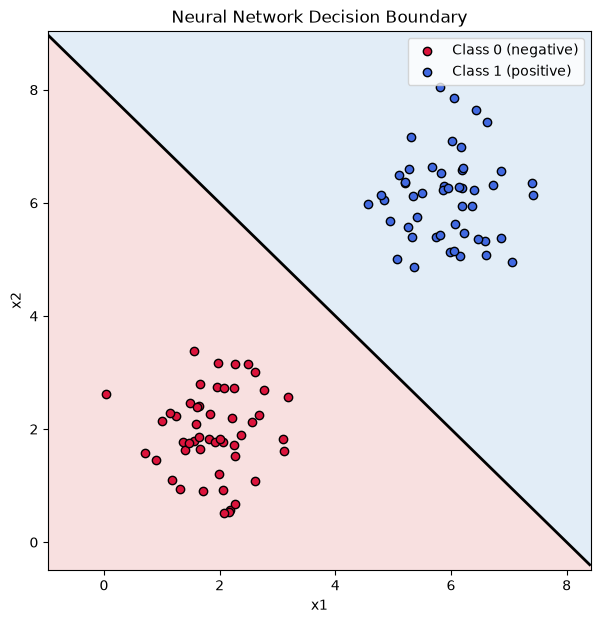

In [18]:
plt.figure(figsize=(7, 7))

plt.contourf(xx1, xx2, grid_predictions, levels=[0, 0.5, 1], colors=['#f4cccc', '#cfe2f3'], alpha=0.6)
plt.contour(xx1, xx2, grid_predictions, levels=[0.5], colors='black', linewidths=2)

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='crimson', label='Class 0 (negative)', edgecolor='k')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='royalblue', label='Class 1 (positive)', edgecolor='k')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Neural Network Decision Boundary')
plt.legend()
plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()